In [1]:
# ====================
# Upload the CSV file
# ====================

from google.colab import files

uploaded = files.upload()

Saving RSM08.20260420T110448.csv to RSM08.20260420T110448.csv


# Load the uploaded CSV and preview the data

In [2]:

import pandas as pd

df = pd.read_csv("RSM08.20260420T110448.csv")

print("Shape:", df.shape)
display(df.head())

Shape: (10912, 5)


,Statistic Label,Month,NACE Group,UNIT,VALUE
0,Retail Sales Index Volume Adjusted,2021 January,Motor trades (45),Base Year 2021=100,83.5
1,Retail Sales Index Volume Adjusted,2021 January,Retail sale in non-specialised stores with foo...,Base Year 2021=100,102.3
2,Retail Sales Index Volume Adjusted,2021 January,Department stores (4719),Base Year 2021=100,65.1
3,Retail Sales Index Volume Adjusted,2021 January,Retail sale of automotive fuel (4730),Base Year 2021=100,77.7
4,Retail Sales Index Volume Adjusted,2021 January,"Retail sale of hardware, paints and glass (4752)",Base Year 2021=100,89.8


# Check columns, data types, and missing values

In [3]:
print("COLUMNS")
print(df.columns.tolist())

print("\nDATA TYPES")
print(df.dtypes)

print("\nMISSING VALUES")
print(df.isna().sum())

print("\nSTATISTIC LABELS")
print(df["Statistic Label"].value_counts())

COLUMNS
['Statistic Label', 'Month', 'NACE Group', 'UNIT', 'VALUE']

DATA TYPES
Statistic Label     object
Month               object
NACE Group          object
UNIT                object
VALUE              float64
dtype: object

MISSING VALUES
Statistic Label      0
Month                0
NACE Group           0
UNIT                 0
VALUE              572
dtype: int64

STATISTIC LABELS
Statistic Label
Retail Sales Index Volume Adjusted                                     1364
Retail Sales Index Volume Adjusted Percentage Change over 1 month      1364
Retail Sales Index Volume Adjusted Percentage Change over 12 months    1364
Retail Sales Index Volume Unadjusted                                   1364
Retail Sales Index Value Adjusted                                      1364
Retail Sales Index Value Adjusted Percentage Change over 1 month       1364
Retail Sales Index Value Adjusted Percentage Change over 12 months     1364
Retail Sales Index Value Unadjusted                          

# Filter the main retail index and clean the dataframe

In [4]:
clean_df = df[df["Statistic Label"] == "Retail Sales Index Volume Adjusted"].copy()

clean_df = clean_df.dropna(subset=["VALUE"])

clean_df = clean_df.rename(columns={
    "Statistic Label": "statistic_label",
    "Month": "month",
    "NACE Group": "nace_group",
    "UNIT": "unit",
    "VALUE": "value"
})

print("Cleaned shape:", clean_df.shape)
display(clean_df.head())

Cleaned shape: (1364, 5)


,statistic_label,month,nace_group,unit,value
0,Retail Sales Index Volume Adjusted,2021 January,Motor trades (45),Base Year 2021=100,83.5
1,Retail Sales Index Volume Adjusted,2021 January,Retail sale in non-specialised stores with foo...,Base Year 2021=100,102.3
2,Retail Sales Index Volume Adjusted,2021 January,Department stores (4719),Base Year 2021=100,65.1
3,Retail Sales Index Volume Adjusted,2021 January,Retail sale of automotive fuel (4730),Base Year 2021=100,77.7
4,Retail Sales Index Volume Adjusted,2021 January,"Retail sale of hardware, paints and glass (4752)",Base Year 2021=100,89.8


# Convert month to a real date and sort the dataset

In [5]:
clean_df["month"] = pd.to_datetime(clean_df["month"], format="%Y %B")

clean_df = clean_df.sort_values(["nace_group", "month"]).reset_index(drop=True)

print("Date range:", clean_df["month"].min(), "to", clean_df["month"].max())
display(clean_df.head())

Date range: 2021-01-01 00:00:00 to 2026-02-01 00:00:00


,statistic_label,month,nace_group,unit,value
0,Retail Sales Index Volume Adjusted,2021-01-01,All retail businesses,Base Year 2021=100,80.0
1,Retail Sales Index Volume Adjusted,2021-02-01,All retail businesses,Base Year 2021=100,89.8
2,Retail Sales Index Volume Adjusted,2021-03-01,All retail businesses,Base Year 2021=100,90.1
3,Retail Sales Index Volume Adjusted,2021-04-01,All retail businesses,Base Year 2021=100,90.4
4,Retail Sales Index Volume Adjusted,2021-05-01,All retail businesses,Base Year 2021=100,100.6


# Check the category list

In [6]:
categories = sorted(clean_df["nace_group"].unique())

print("Total categories:", len(categories))
for c in categories:
    print(c)

Total categories: 22
All retail businesses
All retail businesses, excluding motor trades
All retail businesses, excluding motor trades and bars
All retail businesses, excluding motor trades, automotive fuel and bars
Bars (5630)
Department stores (4719)
Motor trades (45)
Motor trades and automotive fuel (45,4730)
Other retail sales (4753,4763 to 4765,4776 to 4778)
Retail sale in non-specialised stores with food, beverages or tobacco predominating (4711)
Retail sale of automotive fuel (4730)
Retail sale of books, newspapers and stationery (4761,4762)
Retail sale of books, newspapers, stationery and other goods (4753,4761 to 4765,4776 to 4778)
Retail sale of electrical goods (4741 to 4743,4754)
Retail sale of food (4711,4721 to 4729)
Retail sale of food, beverages and tobacco in specialised stores (4721 to 4729)
Retail sale of furniture and lighting (4759)
Retail sale of hardware, paints and glass (4752)
Retail sale of household equipment (4741 to 4743,4752,4754,4759)
Retail sale of non f

In [7]:

keep_categories = [
    "Motor trades (45)",
    "Department stores (4719)",
    "Retail sale of automotive fuel (4730)",
    "Retail sale of hardware, paints and glass (4752)",
    "Retail sale of furniture and lighting (4759)",
    "Retail sale of electrical goods (4741 to 4743,4754)",
    "Retail sale of textiles, clothing and footwear (4751,4771,4772)",
    "Retail sale of books, newspapers, stationery and other goods (4753,4761 to 4765,4776 to 4778)",
    "Other retail sales (4753,4763 to 4765,4776 to 4778)",
    "Retail sale of books, newspapers and stationery (4761,4762)",
    "Retail sale of pharmaceutical, medical and cosmetic articles (4773 to 4775)",
    "Retail sale of food (4711,4721 to 4729)",
    "Retail sale of food, beverages and tobacco in specialised stores (4721 to 4729)",
    "Retail sale of household equipment (4741 to 4743,4752,4754,4759)"
]

final_df = clean_df[clean_df["nace_group"].isin(keep_categories)].copy()

print("Final shape:", final_df.shape)
print("Final categories:", final_df["nace_group"].nunique())
display(final_df.head())

Final shape: (868, 5)
Final categories: 14


,statistic_label,month,nace_group,unit,value
310,Retail Sales Index Volume Adjusted,2021-01-01,Department stores (4719),Base Year 2021=100,65.1
311,Retail Sales Index Volume Adjusted,2021-02-01,Department stores (4719),Base Year 2021=100,83.0
312,Retail Sales Index Volume Adjusted,2021-03-01,Department stores (4719),Base Year 2021=100,77.3
313,Retail Sales Index Volume Adjusted,2021-04-01,Department stores (4719),Base Year 2021=100,55.8
314,Retail Sales Index Volume Adjusted,2021-05-01,Department stores (4719),Base Year 2021=100,107.4


# Create a category summary table

In [8]:
summary_df = (
    final_df
    .groupby("nace_group")
    .agg(
        avg_value=("value", "mean"),
        min_value=("value", "min"),
        max_value=("value", "max"),
        first_month=("month", "min"),
        last_month=("month", "max"),
        observations=("value", "count")
    )
    .reset_index()
    .sort_values("avg_value", ascending=False)
)

summary_df["avg_value"] = summary_df["avg_value"].round(2)
summary_df["min_value"] = summary_df["min_value"].round(2)
summary_df["max_value"] = summary_df["max_value"].round(2)

display(summary_df)

,nace_group,avg_value,min_value,max_value,first_month,last_month,observations
13,"Retail sale of textiles, clothing and footwear...",124.14,26.0,141.7,2021-01-01,2026-02-01,62
4,"Retail sale of books, newspapers and stationer...",121.71,58.3,141.3,2021-01-01,2026-02-01,62
2,"Other retail sales (4753,4763 to 4765,4776 to ...",121.29,65.1,141.1,2021-01-01,2026-02-01,62
5,"Retail sale of books, newspapers, stationery a...",120.52,65.2,134.8,2021-01-01,2026-02-01,62
9,Retail sale of furniture and lighting (4759),113.38,62.0,126.5,2021-01-01,2026-02-01,62
0,Department stores (4719),112.32,55.8,138.4,2021-01-01,2026-02-01,62
1,Motor trades (45),109.86,83.4,132.9,2021-01-01,2026-02-01,62
12,"Retail sale of pharmaceutical, medical and cos...",105.24,80.7,121.1,2021-01-01,2026-02-01,62
3,Retail sale of automotive fuel (4730),103.01,77.7,111.7,2021-01-01,2026-02-01,62
11,Retail sale of household equipment (4741 to 47...,99.65,83.3,113.1,2021-01-01,2026-02-01,62


# Creating charts

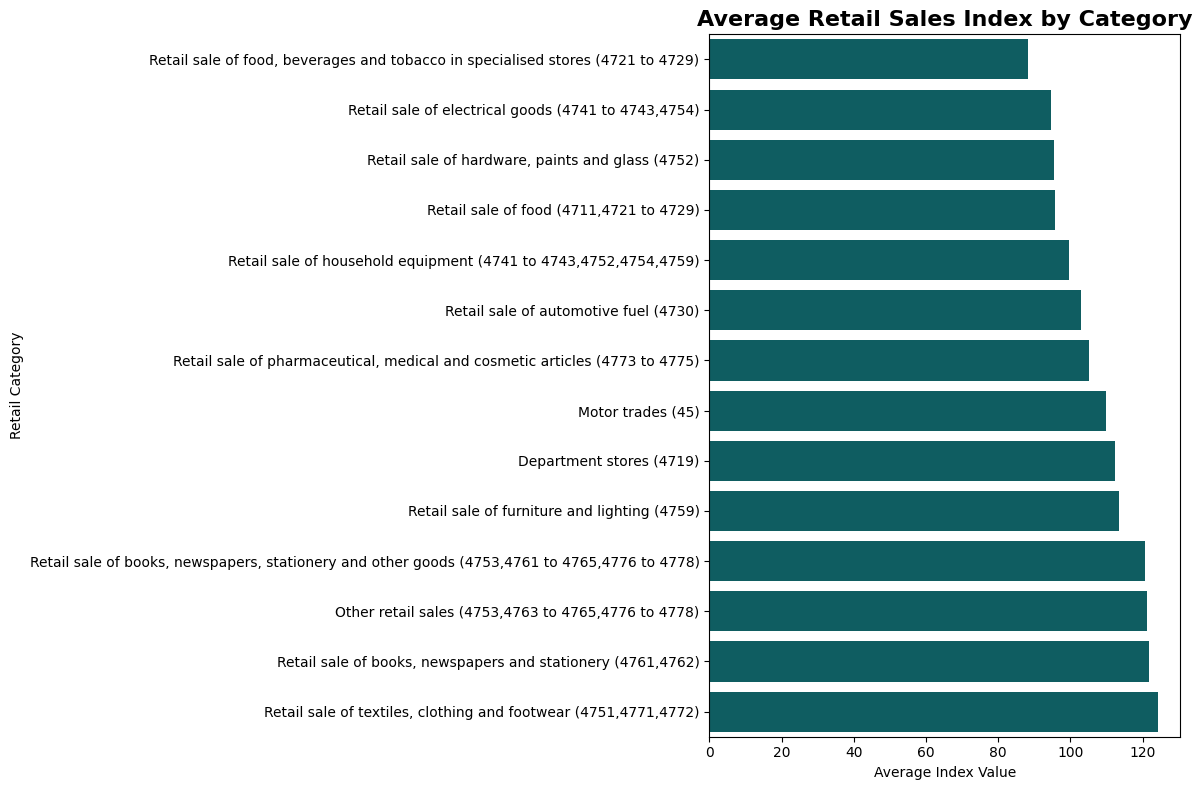

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
chart_df = summary_df.sort_values("avg_value", ascending=True)

sns.barplot(
    data=chart_df,
    x="avg_value",
    y="nace_group",
    color="#01696f"
)

plt.title("Average Retail Sales Index by Category", fontsize=16, weight="bold")
plt.xlabel("Average Index Value")
plt.ylabel("Retail Category")
plt.tight_layout()
plt.show()

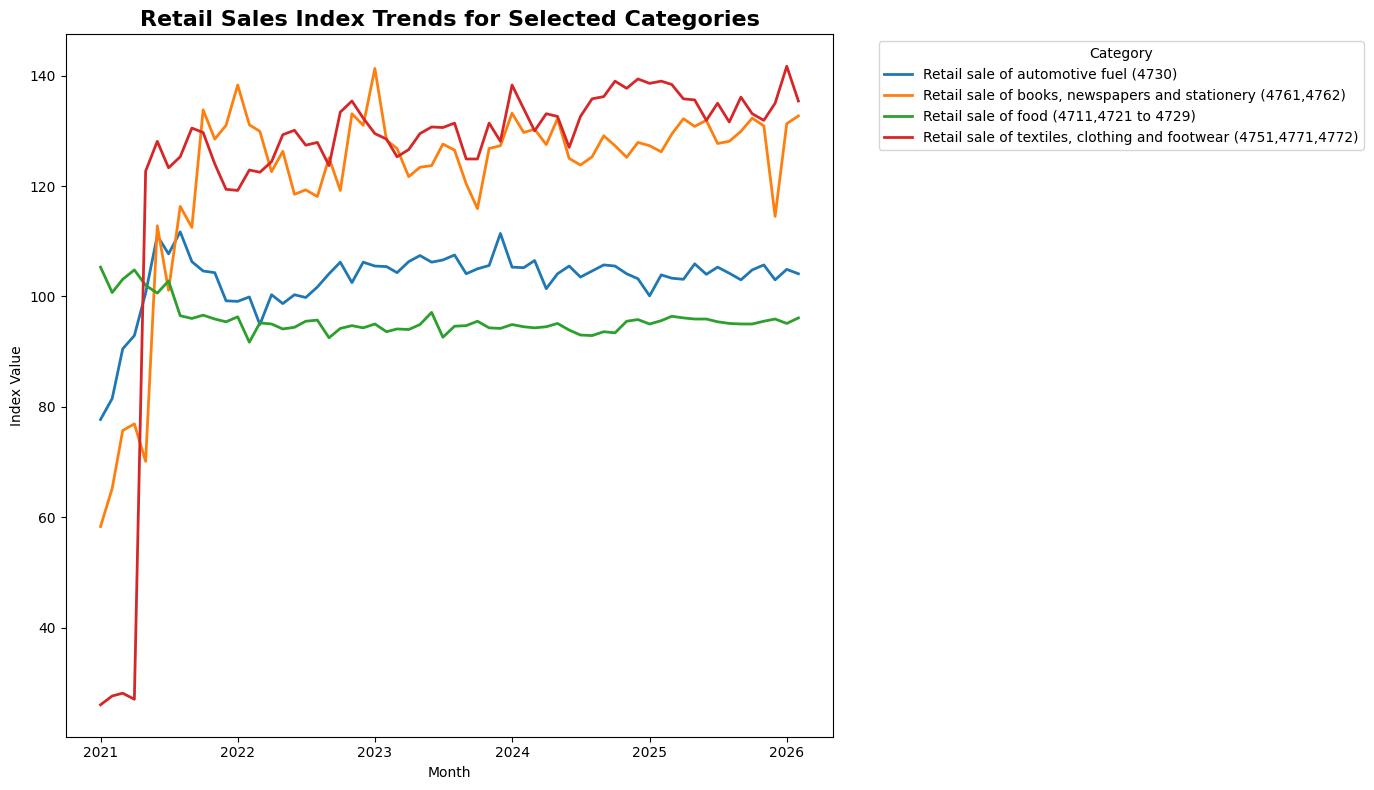

In [17]:
trend_categories = [
    "Retail sale of textiles, clothing and footwear (4751,4771,4772)",
    "Retail sale of books, newspapers and stationery (4761,4762)",
    "Retail sale of food (4711,4721 to 4729)",
    "Retail sale of automotive fuel (4730)"
]

trend_df = final_df[final_df["nace_group"].isin(trend_categories)].copy()

plt.figure(figsize=(14, 8))

sns.lineplot(
    data=trend_df,
    x="month",
    y="value",
    hue="nace_group",
    linewidth=2
)

plt.title("Retail Sales Index Trends for Selected Categories", fontsize=16, weight="bold")
plt.xlabel("Month")
plt.ylabel("Index Value")
plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Calculate month-over-month change

In [11]:
final_df = final_df.sort_values(["nace_group", "month"]).reset_index(drop=True)

final_df["mom_change"] = final_df.groupby("nace_group")["value"].pct_change() * 100

display(final_df.head(10))

,statistic_label,month,nace_group,unit,value,mom_change
0,Retail Sales Index Volume Adjusted,2021-01-01,Department stores (4719),Base Year 2021=100,65.1,NaN
1,Retail Sales Index Volume Adjusted,2021-02-01,Department stores (4719),Base Year 2021=100,83.0,27.496160
2,Retail Sales Index Volume Adjusted,2021-03-01,Department stores (4719),Base Year 2021=100,77.3,-6.867470
3,Retail Sales Index Volume Adjusted,2021-04-01,Department stores (4719),Base Year 2021=100,55.8,-27.813713
4,Retail Sales Index Volume Adjusted,2021-05-01,Department stores (4719),Base Year 2021=100,107.4,92.473118
5,Retail Sales Index Volume Adjusted,2021-06-01,Department stores (4719),Base Year 2021=100,128.9,20.018622
6,Retail Sales Index Volume Adjusted,2021-07-01,Department stores (4719),Base Year 2021=100,112.5,-12.723041
7,Retail Sales Index Volume Adjusted,2021-08-01,Department stores (4719),Base Year 2021=100,110.2,-2.044444
8,Retail Sales Index Volume Adjusted,2021-09-01,Department stores (4719),Base Year 2021=100,112.7,2.268603
9,Retail Sales Index Volume Adjusted,2021-10-01,Department stores (4719),Base Year 2021=100,112.2,-0.443656


# Finding the biggest monthly increases and decreases

In [12]:
top_increases = final_df.dropna(subset=["mom_change"]).sort_values("mom_change", ascending=False).head(10)
top_decreases = final_df.dropna(subset=["mom_change"]).sort_values("mom_change", ascending=True).head(10)

print("TOP 10 MONTHLY INCREASES")
display(top_increases[["month", "nace_group", "value", "mom_change"]])

print("\nTOP 10 MONTHLY DECREASES")
display(top_decreases[["month", "nace_group", "value", "mom_change"]])

TOP 10 MONTHLY INCREASES


,month,nace_group,value,mom_change
810,2021-05-01,"Retail sale of textiles, clothing and footwear...",122.7,354.444444
4,2021-05-01,Department stores (4719),107.4,92.473118
253,2021-06-01,"Retail sale of books, newspapers and stationer...",112.8,60.912981
133,2021-10-01,"Other retail sales (4753,4763 to 4765,4776 to ...",141.1,36.857420
319,2021-10-01,"Retail sale of books, newspapers, stationery a...",134.8,34.129353
1,2021-02-01,Department stores (4719),83.0,27.496160
622,2021-03-01,"Retail sale of hardware, paints and glass (4752)",125.7,24.209486
683,2021-02-01,Retail sale of household equipment (4741 to 47...,102.9,23.529412
63,2021-02-01,Motor trades (45),102.4,22.634731
559,2021-02-01,Retail sale of furniture and lighting (4759),75.6,21.935484



TOP 10 MONTHLY DECREASES


,month,nace_group,value,mom_change
3,2021-04-01,Department stores (4719),55.8,-27.813713
73,2021-12-01,Motor trades (45),83.4,-24.043716
624,2021-05-01,"Retail sale of hardware, paints and glass (4752)",97.0,-19.834711
756,2022-01-01,"Retail sale of pharmaceutical, medical and cos...",97.7,-19.322874
383,2021-12-01,"Retail sale of electrical goods (4741 to 4743,...",88.5,-16.745061
401,2023-06-01,"Retail sale of electrical goods (4741 to 4743,...",83.2,-15.447154
635,2022-04-01,"Retail sale of hardware, paints and glass (4752)",92.1,-13.276836
792,2025-01-01,"Retail sale of pharmaceutical, medical and cos...",99.6,-13.240418
6,2021-07-01,Department stores (4719),112.5,-12.723041
307,2025-12-01,"Retail sale of books, newspapers and stationer...",114.5,-12.528648


# Calculate category volatility

In [13]:

volatility_df = (
    final_df.dropna(subset=["mom_change"])
    .groupby("nace_group")
    .agg(
        avg_value=("value", "mean"),
        avg_mom_change=("mom_change", "mean"),
        volatility=("mom_change", "std")
    )
    .reset_index()
    .sort_values("volatility", ascending=False)
)

volatility_df["avg_value"] = volatility_df["avg_value"].round(2)
volatility_df["avg_mom_change"] = volatility_df["avg_mom_change"].round(2)
volatility_df["volatility"] = volatility_df["volatility"].round(2)

display(volatility_df)

,nace_group,avg_value,avg_mom_change,volatility
13,"Retail sale of textiles, clothing and footwear...",125.74,6.08,45.45
0,Department stores (4719),113.09,1.62,14.19
4,"Retail sale of books, newspapers and stationer...",122.75,1.75,9.89
2,"Other retail sales (4753,4763 to 4765,4776 to ...",122.21,1.38,6.78
5,"Retail sale of books, newspapers, stationery a...",121.43,1.36,6.47
1,Motor trades (45),110.29,0.76,6.23
10,"Retail sale of hardware, paints and glass (4752)",95.63,0.25,6.17
6,"Retail sale of electrical goods (4741 to 4743,...",94.47,0.03,5.98
12,"Retail sale of pharmaceutical, medical and cos...",105.62,0.69,5.61
9,Retail sale of furniture and lighting (4759),114.22,1.20,4.90


# Hidden value score

In [14]:
score_df = volatility_df.copy()

# Normalize columns with min-max scaling
for col in ["avg_value", "avg_mom_change", "volatility"]:
    min_val = score_df[col].min()
    max_val = score_df[col].max()
    score_df[col + "_norm"] = (score_df[col] - min_val) / (max_val - min_val)

# Hidden value score:
# high avg value + high momentum - high volatility
score_df["hidden_value_score"] = (
    0.45 * score_df["avg_value_norm"] +
    0.35 * score_df["avg_mom_change_norm"] +
    0.20 * (1 - score_df["volatility_norm"])
) * 100

score_df = score_df.sort_values("hidden_value_score", ascending=False).reset_index(drop=True)

display(score_df[["nace_group", "avg_value", "avg_mom_change", "volatility", "hidden_value_score"]])

,nace_group,avg_value,avg_mom_change,volatility,hidden_value_score
0,"Retail sale of textiles, clothing and footwear...",125.74,6.08,45.45,80.000000
1,"Retail sale of books, newspapers and stationer...",122.75,1.75,9.89,69.484328
2,"Other retail sales (4753,4763 to 4765,4776 to ...",122.21,1.38,6.78,68.280637
3,"Retail sale of books, newspapers, stationery a...",121.43,1.36,6.47,67.389063
4,Retail sale of furniture and lighting (4759),114.22,1.20,4.90,58.688181
5,Department stores (4719),113.09,1.62,14.19,55.348404
6,Motor trades (45),110.29,0.76,6.23,51.051156
7,"Retail sale of pharmaceutical, medical and cos...",105.62,0.69,5.61,45.414352
8,Retail sale of automotive fuel (4730),103.43,0.53,3.32,43.003487
9,Retail sale of household equipment (4741 to 47...,99.92,0.39,4.44,37.571704


# Visualize the top hidden-value categories

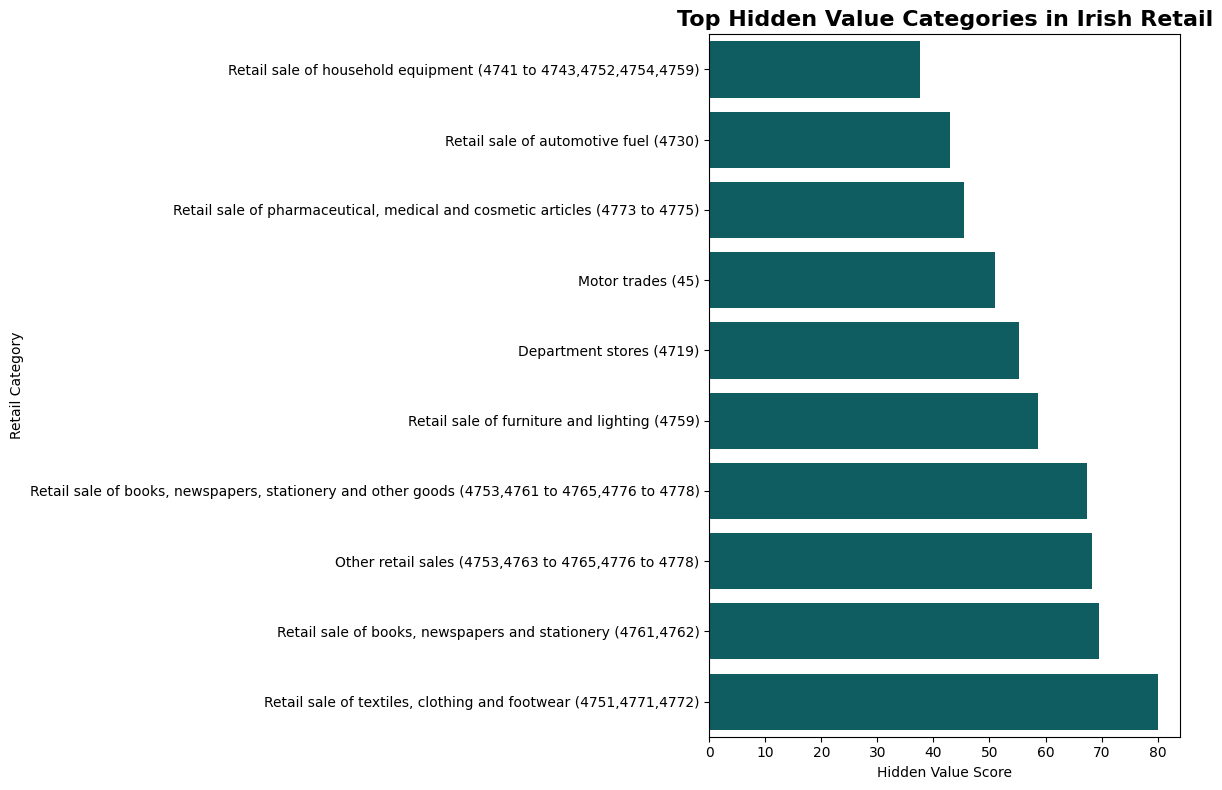

In [15]:
top_score = score_df.head(10).copy()
top_score = top_score.sort_values("hidden_value_score", ascending=True)

plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_score,
    x="hidden_value_score",
    y="nace_group",
    color="#01696f"
)

plt.title("Top Hidden Value Categories in Irish Retail", fontsize=16, weight="bold")
plt.xlabel("Hidden Value Score")
plt.ylabel("Retail Category")
plt.tight_layout()
plt.show()

In [16]:
# ==========================================
# Saving cleaned outputs to CSV
# ==========================================

final_df.to_csv("retail_cleaned_with_mom.csv", index=False)
score_df.to_csv("retail_hidden_value_score.csv", index=False)

print("Saved files:")
print("- retail_cleaned_with_mom.csv")
print("- retail_hidden_value_score.csv")

Saved files:
- retail_cleaned_with_mom.csv
- retail_hidden_value_score.csv
